
# Lab 3: PDE with FDM

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.
2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?

#### **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3** 

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

### Fisica computacional I 
### Estudiante: Laura Velasquez Bolivar 
### Laboratorio 3


### Ejercicio 1 , punto 1


In [1]:
import numpy as np
import time as tm
import matplotlib.pyplot as plt

Nmax = 100

# Pot. ini
V_ini = np.zeros((Nmax, Nmax), float)

# Condición de frontera 
V_ini[:, 0] = 100.0

In [2]:
def Laplace2D_Jacobi(V_ini, tol, max_iter=100000):

    V_old = V_ini.copy()

    error = np.inf
    Niter = 0

    while error > tol and Niter < max_iter:

        V_new = V_old.copy()

        V_new[1:-1, 1:-1] = 0.25 * (
            V_old[2:, 1:-1]
            + V_old[:-2, 1:-1]
            + V_old[1:-1, 2:]
            + V_old[1:-1, :-2]
        )

        error = np.max(
            np.abs(
                V_new[1:-1, 1:-1]
                - V_old[1:-1, 1:-1]
            )
        )

        V_old = V_new.copy()

        Niter += 1

        if Niter % 1000 == 0:
            print("Iteration:", Niter, "Error:", error)

    return V_old, Niter, error

In [3]:
tol = 1e-3

start = tm.process_time()

V, Niter, error = Laplace2D_Jacobi(V_ini, tol)

end = tm.process_time()

print("Tolerance =", tol)
print("Number of iterations =", Niter)
print("Final error =", error)
print("Time (s) =", end - start)

Iteration: 1000 Error: 0.022891133880705183
Iteration: 2000 Error: 0.009252413315472552
Iteration: 3000 Error: 0.004813390549049501
Iteration: 4000 Error: 0.002769498974345197
Iteration: 5000 Error: 0.00165198097892727
Tolerance = 0.001
Number of iterations = 5991
Final error = 0.0009998893285754207
Time (s) = 0.40625


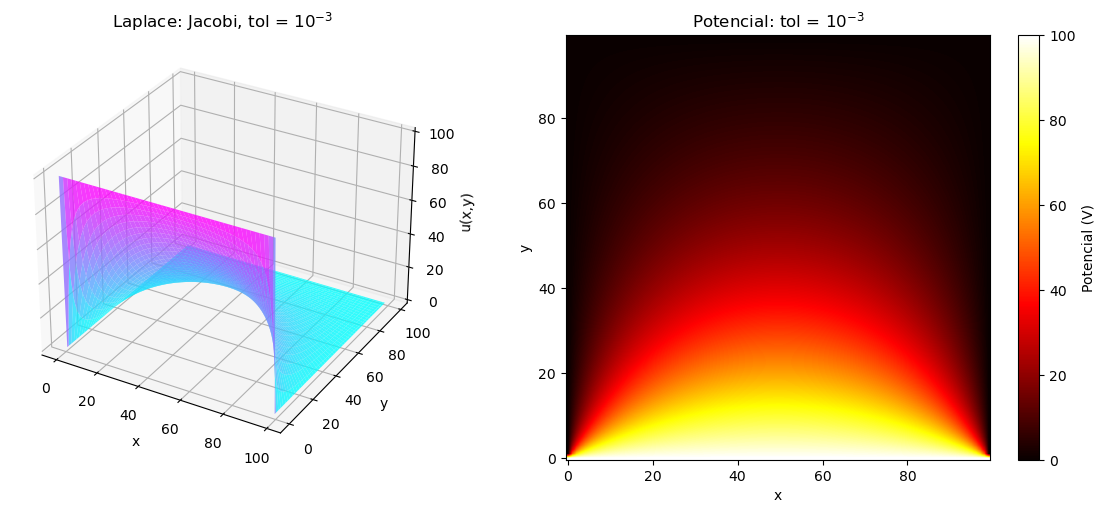

In [5]:
x = np.arange(Nmax)
y = np.arange(Nmax)

X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')

ax1.plot_surface(X, Y, V.T, cmap='cool', alpha=0.8)

ax1.set_title(r"Laplace: Jacobi, tol = $10^{-3}$")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("u(x,y)")


ax2 = fig.add_subplot(1, 2, 2)

im = ax2.imshow(
    V.T,
    origin='lower',
    cmap='hot',
    interpolation='bilinear'
)

ax2.set_title(r"Potencial: tol = $10^{-3}$")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

fig.colorbar(im, ax=ax2, label="Potencial (V)")

plt.tight_layout()
plt.show()



### Parte 1. Diferencias finitas con método de Jacobi

Se resolvió numéricamente la ecuación de Laplace utilizando el método de diferencias finitas y el esquema de Jacobi. Se fijó el borde inferior en \(100\,V\) y los otros tres bordes en \(0\,V\). En cada iteración, el potencial de los puntos interiores se calculó a partir del promedio de sus cuatro vecinos.

El proceso se repitió hasta que el cambio máximo entre dos iteraciones consecutivas fue menor que la tolerancia solicitada, 
$\mathrm{tol} = 10^{-3}$ 


La gráfica obtenida muestra que el potencial alcanza su valor máximo en el borde fijado a \(100\,V\) y disminuye gradualmente hacia los bordes establecidos en \(0\,V\). Este comportamiento es consistente con lo esperado para una solución de la ecuación de Laplace.


### Ejercicio 1 , punto 2 


In [6]:
def Fourier_Laplace(Nterms, Nmax=100, V0=100.0):

    L = Nmax - 1

    x = np.arange(Nmax, dtype=float)
    y = np.arange(Nmax, dtype=float)

    X, Y = np.meshgrid(x, y)

    U = np.zeros((Nmax, Nmax), float)

    for k in range(Nterms):

        n = 2*k + 1   # 1, 3, 5, 7, ...

        # Parte espacial en x
        sin_term = np.sin(n*np.pi*X/L)

        # Forma estable de sinh[n*pi*(L-y)/L] / sinh(n*pi)
        ratio = (
            np.exp(-n*np.pi*Y/L)
            *
            (1 - np.exp(-2*n*np.pi*(1 - Y/L)))
            /
            (1 - np.exp(-2*n*np.pi))
        )

        U += (
            4*V0/(np.pi*n)
            * sin_term
            * ratio
        )

    return U

In [7]:
Nref = 2000

U_ref = Fourier_Laplace(Nref)

In [10]:
tol_fourier = 1e-4

Nref = 2000
U_ref = Fourier_Laplace(Nref)

Nterms = 1
error_fourier = np.inf

while error_fourier > tol_fourier:

    U_fourier = Fourier_Laplace(Nterms)

    # Error int
    error_fourier = np.max(
        np.abs(
            U_fourier[1:-1, 1:-1]
            - U_ref[1:-1, 1:-1]
        )
    )

    if Nterms % 20 == 0:
        print(
            "Terminos:",
            Nterms,
            "Error:",
            error_fourier
        )

    Nterms += 1


Nterms -= 1

print("\nResultado Fourier")
print("Tolerancia =", tol_fourier)
print("Numero de terminos =", Nterms)
print("indice armonico n =", 2*Nterms - 1)
print(" error final=", error_fourier)

Terminos: 20 Error: 6.988140642676704
Terminos: 40 Error: 0.42889973032968953
Terminos: 60 Error: 0.22668621796032085
Terminos: 80 Error: 0.03283261707987606
Terminos: 100 Error: 0.00814274729523845
Terminos: 120 Error: 0.0024052617793017816
Terminos: 140 Error: 0.00018928828127684483
Terminos: 160 Error: 0.00016346052378679587

Resultado Fourier
Tolerancia = 0.0001
Numero de terminos = 167
indice armonico n = 333
 error final= 9.506611946363819e-05


In [11]:
V

array([[1.00000000e+02, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+02, 4.99868029e+01, 3.02083425e+01, ...,
        1.84207924e-02, 9.20358519e-03, 0.00000000e+00],
       [1.00000000e+02, 6.97388735e+01, 4.99472202e+01, ...,
        3.68220174e-02, 1.83973959e-02, 0.00000000e+00],
       ...,
       [1.00000000e+02, 6.97388735e+01, 4.99472202e+01, ...,
        3.68220174e-02, 1.83973959e-02, 0.00000000e+00],
       [1.00000000e+02, 4.99868029e+01, 3.02083425e+01, ...,
        1.84207924e-02, 9.20358519e-03, 0.00000000e+00],
       [1.00000000e+02, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [12]:
U_fourier

array([[ 0.00000000e+00,  1.02781692e+02,  1.01999355e+02, ...,
         1.01999355e+02,  1.02781692e+02,  2.64986043e-12],
       [ 0.00000000e+00,  4.99889307e+01,  7.04609588e+01, ...,
         7.04609588e+01,  4.99889307e+01,  3.02775526e-13],
       [ 0.00000000e+00,  2.94944018e+01,  4.99553425e+01, ...,
         4.99553425e+01,  2.94944018e+01,  1.35745653e-13],
       ...,
       [ 0.00000000e+00,  2.23404864e-02,  4.46574644e-02, ...,
         4.46574644e-02,  2.23404864e-02, -2.24712509e-16],
       [ 0.00000000e+00,  1.11643688e-02,  2.23169917e-02, ...,
         2.23169917e-02,  1.11643688e-02, -1.12300683e-16],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

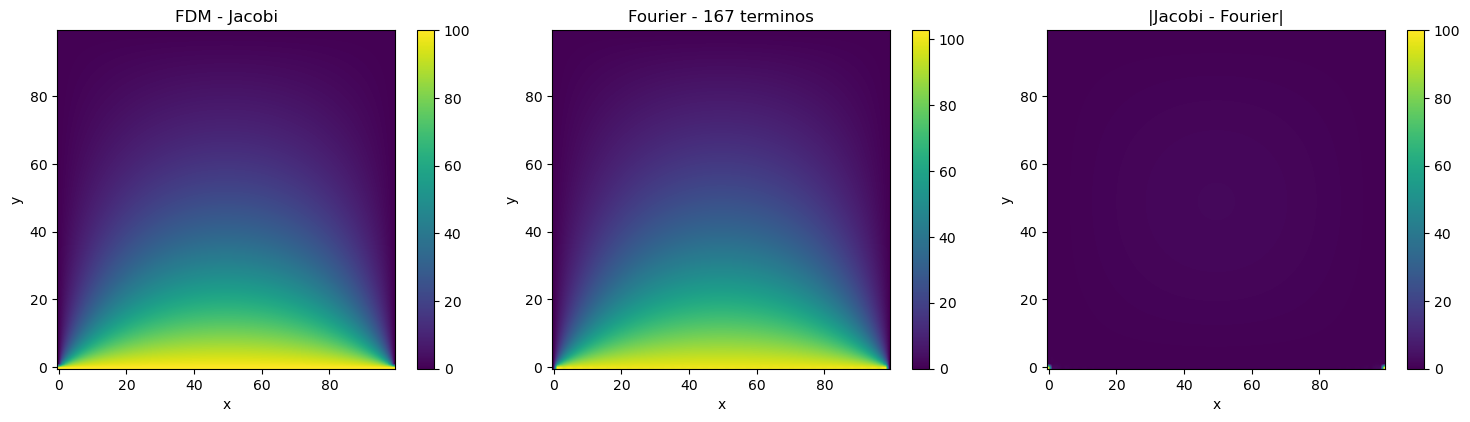

In [13]:
fig = plt.figure(figsize=(15, 4))

# Jacobi
ax1 = fig.add_subplot(1, 3, 1)

im1 = ax1.imshow(
    V.T,
    origin='lower',
    interpolation='bilinear'
)

ax1.set_title("FDM - Jacobi")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

fig.colorbar(im1, ax=ax1)


# Fourier
ax2 = fig.add_subplot(1, 3, 2)

im2 = ax2.imshow(
    U_fourier,
    origin='lower',
    interpolation='bilinear'
)

ax2.set_title(
    f"Fourier - {Nterms} terminos"
)

ax2.set_xlabel("x")
ax2.set_ylabel("y")

fig.colorbar(im2, ax=ax2)


# Diferencia
ax3 = fig.add_subplot(1, 3, 3)

difference = np.abs(
    V.T - U_fourier
)

im3 = ax3.imshow(
    difference,
    origin='lower',
    interpolation='bilinear'
)

ax3.set_title("|Jacobi - Fourier|")
ax3.set_xlabel("x")
ax3.set_ylabel("y")

fig.colorbar(im3, ax=ax3)

plt.tight_layout()
plt.show()

In [14]:
V_compare, Niter_compare, error_compare = Laplace2D_Jacobi(
    V_ini,
    1e-6
)

Iteration: 1000 Error: 0.022891133880705183
Iteration: 2000 Error: 0.009252413315472552
Iteration: 3000 Error: 0.004813390549049501
Iteration: 4000 Error: 0.002769498974345197
Iteration: 5000 Error: 0.00165198097892727
Iteration: 6000 Error: 0.000995354643642088
Iteration: 7000 Error: 0.0006011324049772782
Iteration: 8000 Error: 0.0003632397963961864
Iteration: 9000 Error: 0.00021951034266720626
Iteration: 10000 Error: 0.00013265841674936496
Iteration: 11000 Error: 8.017209736621567e-05
Iteration: 12000 Error: 4.845244884776889e-05
Iteration: 13000 Error: 2.928263281631871e-05
Iteration: 14000 Error: 1.769723451872096e-05
Iteration: 15000 Error: 1.0695500446189499e-05
Iteration: 16000 Error: 6.463935466882731e-06
Iteration: 17000 Error: 3.906546574228287e-06
Iteration: 18000 Error: 2.3609622594733537e-06
Iteration: 19000 Error: 1.4268722843269188e-06


### Parte 2. Comparación con la serie de Fourier

Para comparar con el método numérico, se resolvió el mismo problema mediante una serie de Fourier. Como las condiciones de frontera hacen que solo contribuyan los modos impares, se fueron agregando progresivamente términos de la serie hasta que el error respecto a una solución de referencia fue menor que

$\mathrm{tol} = 10^{-4}$

Utilizando el criterio de convergencia implementado en el código, se necesitaron aproximadamente 167 términos no nulos de la serie de Fourier para alcanzar la tolerancia de $\mathrm 10^{-4}$.

Así, los dos métodos llegan a la misma distribución de potencial, pero la convergencia se controla de forma diferente: en Jacobi se aumentan las iteraciones hasta cumplir la tolerancia, mientras que en Fourier se aumenta el número de términos de la serie.

### Ejercicio 3 , punto 1



In [15]:
import numpy as np
import matplotlib.pyplot as plt

Nmax = 100

# Pot. INI
V_ini = np.zeros((Nmax, Nmax), float)

# PLACAS POSICION
y1 = 45
y2 = 65

x_positive = 45
x_negative = 55

# POT PLACAS
V_ini[y1:y2, x_positive] = 50.0
V_ini[y1:y2, x_negative] = -50.0

In [16]:
plates = np.zeros((Nmax, Nmax), dtype=bool)

plates[y1:y2, x_positive] = True
plates[y1:y2, x_negative] = True

In [17]:
Niter = 300

In [18]:
def capacitor_df(V_ini, plates, Niter):

    V = V_ini.copy()

    for k in range(Niter):

        V_new = V.copy()

        V_new[1:-1, 1:-1] = 0.25 * (
            V[2:, 1:-1] +
            V[:-2, 1:-1] +
            V[1:-1, 2:] +
            V[1:-1, :-2]
        )

        # Conservar potencial
        V_new[plates] = V_ini[plates]

        V = V_new

    return V

In [19]:
Niter = 300

V = capacitor_df(V_ini, plates, Niter)

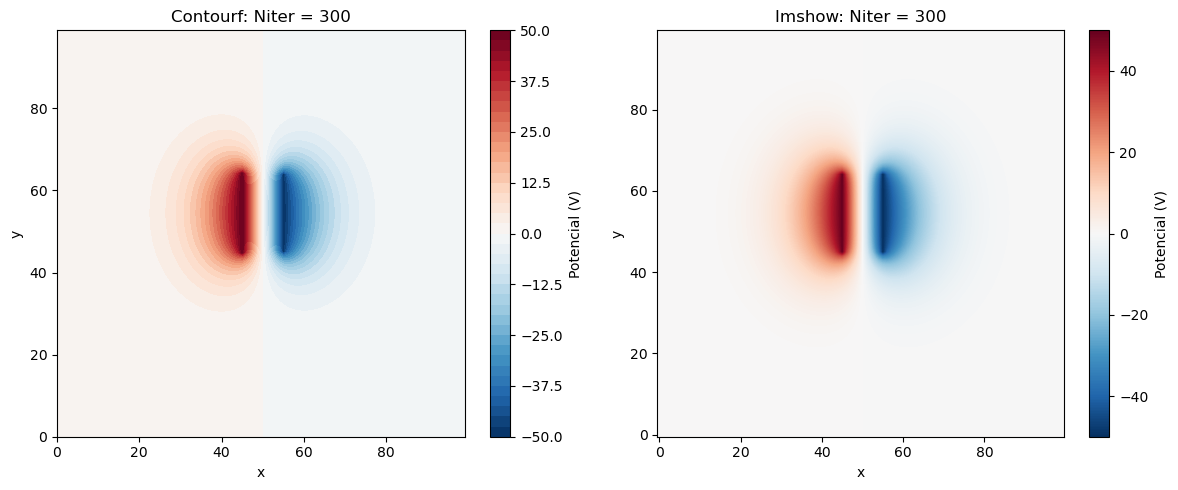

In [21]:
fig = plt.figure(figsize=(12,5))

# Contour
ax1 = fig.add_subplot(1,2,1)

c1 = ax1.contourf(
    V,
    levels=40,
    cmap='RdBu_r'
)

ax1.set_title(f'Contourf: Niter = {Niter}')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

fig.colorbar(c1, ax=ax1, label='Potencial (V)')


# Imshow
ax2 = fig.add_subplot(1,2,2)

im = ax2.imshow(
    V,
    origin='lower',
    cmap='RdBu_r',
    interpolation='bilinear'
)

ax2.set_title(f'Imshow: Niter = {Niter}')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

fig.colorbar(im, ax=ax2, label='Potencial (V)')

plt.tight_layout()
plt.show()

Se aplicó el método iterativo para resolver la ecuación de Laplace en todos los puntos de la región, manteniendo constantes los valores de potencial establecidos en las placas. El resultado permite observar cómo el potencial eléctrico cambia gradualmente desde valores positivos cerca de una placa hasta valores negativos alrededor de la otra. Además, se puede apreciar que las líneas de potencial se curvan cerca de los extremos de las placas debido a la distribución del campo eléctrico en esa zona.

### Ejercicio 3 , punto 2 

In [22]:
# Espaciado de la malla
dx = 1.0
dy = 1.0

# Componentes del campo eléctrico
Ex = np.zeros_like(V)
Ey = np.zeros_like(V)

# Derivada central respecto a x
Ex[1:-1, 1:-1] = -(
    V[1:-1, 2:] - V[1:-1, :-2]
) / (2*dx)

# Derivada central respecto a y
Ey[1:-1, 1:-1] = -(
    V[2:, 1:-1] - V[:-2, 1:-1]
) / (2*dy)

# Magnitud del campo
E = np.sqrt(Ex**2 + Ey**2)

In [23]:
plates

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [24]:
Ex[plates] = 0.0
Ey[plates] = 0.0
E[plates] = 0.0

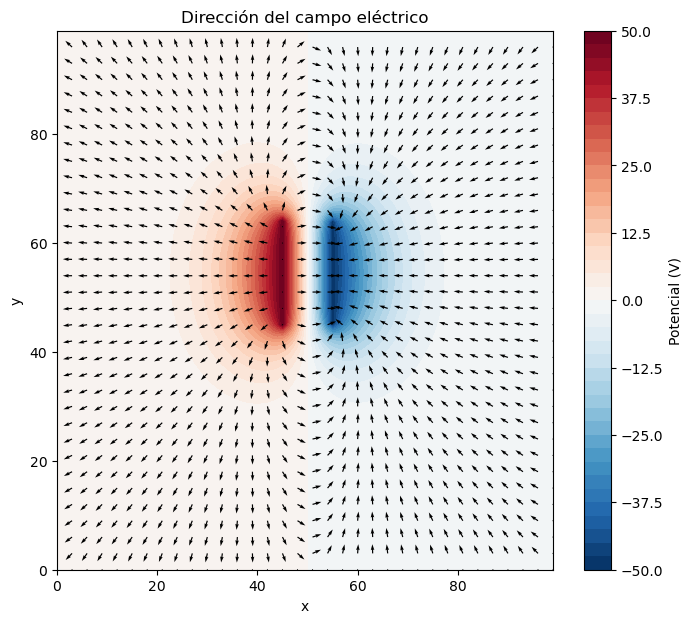

In [25]:
# Magnitud
Emag = np.sqrt(Ex**2 + Ey**2)

# Evit división por cero
Ex_norm = np.divide(
    Ex, Emag,
    out=np.zeros_like(Ex),
    where=Emag != 0
)

Ey_norm = np.divide(
    Ey, Emag,
    out=np.zeros_like(Ey),
    where=Emag != 0
)

step = 3

fig, ax = plt.subplots(figsize=(8,7))

contour = ax.contourf(
    X, Y, V,
    levels=40,
    cmap='RdBu_r'
)

fig.colorbar(
    contour,
    ax=ax,
    label='Potencial (V)'
)

ax.quiver(
    X[::step, ::step],
    Y[::step, ::step],
    Ex_norm[::step, ::step],
    Ey_norm[::step, ::step],
    color='black'
)

ax.set_title('Dirección del campo eléctrico')
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.show()

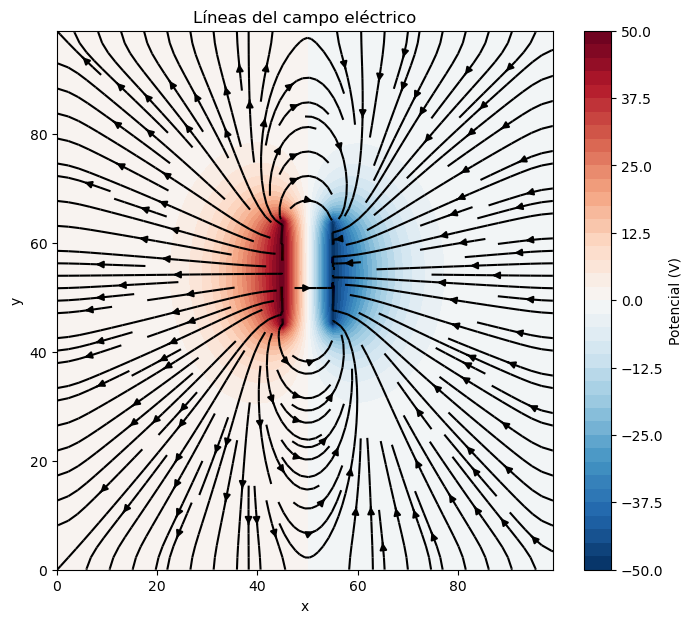

In [52]:
fig, ax = plt.subplots(figsize=(8, 7))

contour = ax.contourf(
    X, Y, V,
    levels=40,
    cmap='RdBu_r'
)

fig.colorbar(
    contour,
    ax=ax,
    label='Potencial (V)'
)

ax.streamplot(
    X, Y,
    Ex, Ey,
    density=1.5,
    color='black'
)

ax.set_title('Líneas del campo eléctrico')
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.show()


 se analizaron los cambios del potencial entre los diferentes puntos de la región y así se determinaron las componentes $\(E_x\)$y $\(E_y\)$. 

la gráfica de los vectores permite observar que el campo eléctrico va desde la placa que tiene mayor potencial hacia la que tiene menor potencial. En la zona central entre las placas, el campo mantiene una dirección bastante uniforme, mientras que cerca de los extremos las líneas comienzan a desviarse debido al efecto de borde.

el  método  de diferencias finitas permite conocer ncómo se distribuye el potencial eléctrico y  también cómo se comporta el campo eléctrico alrededor de las placas, incluyendo su dirección y su intensidad.